# Análise de Sinistros nas Rodovias Federais do Brasil

**Integrantes:** Andre Luis Soares Ferreira, Helena Couto dos Santos, Juliana Fernandes Barreto, Mariana Esthefany Xavier dos Santos

## Introdução

Sinistros de trânsito nas rodovias federais respondem por parte significativa das mortes evitáveis
no Brasil, e boa parte do debate público sobre segurança viária foca em fatores da via ou do
condutor, dando menos atenção às características do próprio veículo. Este trabalho investiga se
veículos com melhor avaliação de segurança (Latin NCAP) e maior valor médio de mercado (Tabela
FIPE) estão associados a menor gravidade entre os envolvidos em sinistros nas rodovias federais do
Brasil.

A análise cruza os Dados Abertos da Polícia Rodoviária Federal (PRF), que registram cada sinistro
por ocorrência, por pessoa envolvida e por veículo, com informações externas de segurança veicular
do Latin NCAP e de valor de mercado da Tabela FIPE, obtidas por normalização e casamento do campo de
marca/modelo informado pela PRF.

O recorte é nacional (rodovias federais do Brasil) e temporal (2010 a 2026, sendo 2026 um ano ainda
incompleto na base, tratado separadamente nas análises de tendência). A abordagem é associativa, não
causal: o objetivo é descrever padrões e proporções observadas na base, não isolar o efeito de
nenhuma variável sobre a gravidade dos sinistros, nem estimar risco por exposição ao tráfego. Os
resultados também não representam a frota completa de veículos leves do país, apenas os veículos e
sinistros presentes neste recorte enriquecido.

Ao longo do relatório, oito perguntas orientam a análise:

1. Como o volume e a proporção de pessoas com desfecho grave/fatal evoluíram ao longo do período?
2. Em quais combinações de dia da semana e período do dia a gravidade observada é maior?
3. Como a gravidade varia entre os diferentes tipos de sinistro?
4. Como condições da via e do ambiente (tipo de pista, uso do solo, fase do dia, condição
   meteorológica) se associam à gravidade?
5. Existe um gradiente descritivo entre a gravidade e a avaliação de segurança Latin NCAP / o valor
   de mercado FIPE dos veículos?
6. Essa associação se sustenta em uma regressão linear com controles observáveis?
7. Onde os casos graves/fatais se concentram geograficamente?
8. Como essa relação varia entre tipos de sinistro, e quão sensível é ao critério de pareamento com
   o Latin NCAP?

## Dados usados

### Fontes
- Dados Abertos da PRF (acidentes agrupados por ocorrência e por pessoa/veículo)
- Tabela FIPE (valor médio de mercado)
- Latin NCAP (avaliação de segurança veicular)

### Carga dos dados

O arquivo `acidentes_2010_2026_carros_latin_ncap.csv` (~600MB) é lido em blocos. O separador é `;` e a codificação `utf-8`, conforme o pipeline de
tratamento (`build_prf_multiyear.py`).

In [23]:
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns

sns.set_palette('Set2')
pd.set_option("display.max_columns", 100)

In [2]:
CAMINHO_CSV = "data/acidentes_2010_2026_carros_latin_ncap.csv"
TAMANHO_BLOCO = 200_000

blocos = []
for bloco in pd.read_csv(
    CAMINHO_CSV,
    sep=";",
    encoding="utf-8",
    chunksize=TAMANHO_BLOCO,
    low_memory=False,
):
    blocos.append(bloco)

df = pd.concat(blocos, ignore_index=True)
del blocos

print(f"Linhas carregadas: {len(df):,} | Colunas: {df.shape[1]}")

Linhas carregadas: 564,154 | Colunas: 88


### Diagnóstico inicial da base

In [3]:
print("Formato (linhas, colunas):", df.shape)
df.info()

print("\nAnos cobertos (ano_base):")
print(df["ano_base"].value_counts().sort_index())

print("\nSinistros únicos:", df["id"].nunique())
print("Pessoas (linhas):", len(df))

Formato (linhas, colunas): (564154, 88)
<class 'pandas.DataFrame'>
RangeIndex: 564154 entries, 0 to 564153
Data columns (total 88 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   ano_base                                  564154 non-null  int64  
 1   arquivo_origem_enriquecido                564154 non-null  str    
 2   id                                        564154 non-null  float64
 3   pesid                                     564154 non-null  int64  
 4   data_inversa                              564154 non-null  str    
 5   dia_semana                                564154 non-null  str    
 6   horario                                   564154 non-null  str    
 7   uf                                        564154 non-null  str    
 8   br                                        564154 non-null  object 
 9   km                                        564154 non-null  str 

### Diagnóstico de valores ausentes

`latin_ncap_estrelas_min/max` e os `percentual_*` têm ausência acima de 90% e não serão usados nas análises.

In [4]:
ausentes = df.isna().mean().sort_values(ascending=False) * 100
ausentes = ausentes[ausentes > 0]
ausentes

latin_ncap_estrelas_min                  94.951733
latin_ncap_percentual_crianca_max        94.951733
latin_ncap_percentual_crianca_min        94.951733
latin_ncap_percentual_adulto_max         94.951733
latin_ncap_percentual_adulto_min         94.951733
latin_ncap_estrelas_max                  94.951733
naturalidade                             52.961603
uop                                      50.520071
delegacia                                50.495787
regional                                 50.476466
longitude                                50.472389
latitude                                 50.472389
mortos                                   50.472389
feridos_graves                           50.472389
feridos_leves                            50.472389
ilesos                                   50.472389
nacionalidade                            49.663213
latin_ncap_estrelas_crianca_min           4.445949
latin_ncap_estrelas_crianca_max           4.445949
latin_ncap_estrelas_adulto_min 

## Pré-processamento

### Colunas fora do escopo desta análise

As colunas `ilesos`, `feridos_leves`, `feridos_graves`, `mortos`, `latitude`, `longitude`,
`regional`, `delegacia` e `uop` pertencem ao arquivo de ocorrência da PRF e não chegam a ser
unidas por pessoa no pipeline de tratamento, por isso ficam majoritariamente vazias.

In [6]:
colunas_fora_do_escopo = [
    "ilesos", "feridos_leves", "feridos_graves", "mortos",
    "latitude", "longitude", "regional", "delegacia", "uop",
]
df = df.drop(columns=colunas_fora_do_escopo, errors="ignore")
print(f"Colunas restantes: {df.shape[1]}")

Colunas restantes: 79


### Harmonização de texto

Diversas colunas categóricas da PRF variam em acento, caixa e nomenclatura ao longo dos anos. Aplicamos limpeza genérica de texto e, onde a variação é semântica (não só grafia), um mapa explícito para categorias canônicas.

In [7]:
def remover_acentos(texto):
    nfkd = unicodedata.normalize("NFKD", texto)
    return "".join(c for c in nfkd if not unicodedata.combining(c))

def limpar_texto(valor):
    if pd.isna(valor):
        return np.nan
    texto = remover_acentos(str(valor)).strip().upper()
    return " ".join(texto.split())

**`estado_fisico`**: nomenclatura mudou ao longo dos anos (`Lesões Leves` = `Ferido Leve`, `Óbito` = `Morto`).

In [8]:
MAPA_ESTADO_FISICO = {
    "ILESO": "Ileso",
    "FERIDO LEVE": "Ferido Leve", "LESOES LEVES": "Ferido Leve",
    "FERIDO GRAVE": "Ferido Grave", "LESOES GRAVES": "Ferido Grave",
    "OBITO": "Óbito", "MORTO": "Óbito",
    "IGNORADO": "Ignorado", "NAO INFORMADO": "Ignorado",
}

df["estado_fisico"] = df["estado_fisico"].apply(limpar_texto).map(MAPA_ESTADO_FISICO)
df["estado_fisico"].value_counts(dropna=False)

estado_fisico
Ileso           375076
Ferido Leve     136416
Ferido Grave     31782
Óbito            10003
Ignorado          9945
NaN                932
Name: count, dtype: int64

**`dia_semana`**: forma curta (`SEGUNDA`) e longa (`SEGUNDA-FEIRA`) coexistem; unificamos para a forma longa.

In [9]:
MAPA_DIA_SEMANA = {
    "DOMINGO": "DOMINGO",
    "SEGUNDA": "SEGUNDA-FEIRA", "SEGUNDA-FEIRA": "SEGUNDA-FEIRA",
    "TERCA": "TERCA-FEIRA", "TERCA-FEIRA": "TERCA-FEIRA",
    "QUARTA": "QUARTA-FEIRA", "QUARTA-FEIRA": "QUARTA-FEIRA",
    "QUINTA": "QUINTA-FEIRA", "QUINTA-FEIRA": "QUINTA-FEIRA",
    "SEXTA": "SEXTA-FEIRA", "SEXTA-FEIRA": "SEXTA-FEIRA",
    "SABADO": "SABADO",
}

df["dia_semana"] = df["dia_semana"].apply(limpar_texto).map(MAPA_DIA_SEMANA)
df["dia_semana"].value_counts(dropna=False)

dia_semana
DOMINGO          99704
SABADO           92579
SEXTA-FEIRA      92056
SEGUNDA-FEIRA    77764
QUINTA-FEIRA     70655
QUARTA-FEIRA     66346
TERCA-FEIRA      65050
Name: count, dtype: int64

**`uso_solo`**: até 2016 a PRF usa `Urbano`/`Rural`; de 2017 em diante passa a usar `Sim`/`Não` para a mesma pergunta (é área urbana?). Unificamos para `Urbano`/`Rural`.

In [10]:
MAPA_USO_SOLO = {"SIM": "URBANO", "NAO": "RURAL", "URBANO": "URBANO", "RURAL": "RURAL"}

df["uso_solo"] = df["uso_solo"].apply(limpar_texto).map(MAPA_USO_SOLO)
df["uso_solo"].value_counts(dropna=False)

uso_solo
RURAL     297358
URBANO    266793
NaN            3
Name: count, dtype: int64

**Demais colunas categóricas**: só limpeza de acento/caixa/espaço, sem remapeamento semântico. **Nota:** `tracado_via` tem valores compostos (ex.: `RETA;DECLIVE`) por ser campo de múltipla escolha, mantido como está.

In [11]:
colunas_categoricas = [
    "causa_acidente", "tipo_acidente", "condicao_metereologica",
    "tipo_pista", "tracado_via", "fase_dia", "municipio",
]

for coluna in colunas_categoricas:
    df[coluna] = df[coluna].apply(limpar_texto)

### Ano de referência, datas, hora e período do dia

`ano_base` é o ano de referência usado nas análises de tendência (100% preenchido). `data_inversa` também é convertida para uso onde granularidade de dia/mês for necessária: até 2015 o ano vem com 4 dígitos (`DD/MM/AAAA`), de 2016 em diante com 2 dígitos (`DD/MM/AA`).

In [12]:
def parse_data_flexivel(serie):
    convertida = pd.to_datetime(serie, format="%d/%m/%Y", errors="coerce")
    faltantes = convertida.isna()
    convertida.loc[faltantes] = pd.to_datetime(
        serie[faltantes], format="%d/%m/%y", errors="coerce"
    )
    return convertida

df["data_inversa"] = parse_data_flexivel(df["data_inversa"])
print("Ainda não convertidas:", df["data_inversa"].isna().sum(), "de", len(df))

Ainda não convertidas: 279412 de 564154


`horario` é convertido em hora (0-23) e agrupado em período do dia. Isso é diferente de `fase_dia` (que é a fase de luz natural já registrada pela PRF); período do dia aqui é um agrupamento de relógio.

In [13]:
df["hora"] = pd.to_datetime(df["horario"], format="%H:%M:%S", errors="coerce").dt.hour

def periodo_do_dia(hora):
    if pd.isna(hora):
        return np.nan
    if 0 <= hora < 6:
        return "Madrugada"
    if 6 <= hora < 12:
        return "Manhã"
    if 12 <= hora < 18:
        return "Tarde"
    return "Noite"

df["periodo_dia"] = df["hora"].apply(periodo_do_dia)
df["periodo_dia"].value_counts(dropna=False)

periodo_dia
Tarde        195154
Manhã        169531
Noite        147074
Madrugada     52395
Name: count, dtype: int64

### Definição do desfecho (gravidade)

In [14]:
df["grave_fatal"] = df["estado_fisico"].isin(["Ferido Grave", "Óbito"])
df["grave_fatal"].value_counts(normalize=True) * 100

grave_fatal
False    92.593334
True      7.406666
Name: proportion, dtype: float64

### Base `validos`: pessoas com desfecho conhecido

Remove `Ignorado`, já que taxas de gravidade não devem ser calculadas sobre desfecho desconhecido.

In [15]:
CATEGORIAS_DESFECHO_CONHECIDO = ["Ileso", "Ferido Leve", "Ferido Grave", "Óbito"]

validos = df[df["estado_fisico"].isin(CATEGORIAS_DESFECHO_CONHECIDO)].copy()
print("Pessoas com desfecho conhecido:", len(validos), "de", len(df))

Pessoas com desfecho conhecido: 553277 de 564154


**Ano parcial:** `ano_base == 2026` está incompleto. Para tendência temporal ou qualquer modelo, filtrar por `ano_base <= ANO_MAXIMO_COMPLETO`. Isso não é aplicado por padrão em `validos` porque nem toda pergunta é sobre tendência.

In [16]:
ANO_MAXIMO_COMPLETO = 2025  # usar validos[validos["ano_base"] <= ANO_MAXIMO_COMPLETO] em tendências/modelos

### Filtro de amostra mínima (uso compartilhado)

Várias perguntas comparam taxas entre categorias e precisam de um limiar mínimo de observações para a categoria entrar no ranking/comparação (evita taxa de 100% baseada em 2 casos). Definimos um limiar único e uma função reutilizável, assim todo mundo usa o mesmo critério, sem reescrever a lógica em cada pergunta.

In [17]:
N_MINIMO = 30  # limiar mínimo de observações por categoria em rankings/comparações

def taxa_por_categoria(base, coluna_categoria, coluna_alvo="grave_fatal", minimo=N_MINIMO):
    """Agrupa por coluna_categoria, calcula n, contagem de casos e taxa (%),
    e mantém só categorias com pelo menos `minimo` observações."""
    resumo = base.groupby(coluna_categoria)[coluna_alvo].agg(n="size", positivos="sum")
    resumo["taxa"] = resumo["positivos"] / resumo["n"] * 100
    return resumo[resumo["n"] >= minimo].sort_values("taxa", ascending=False)

# exemplo de uso: taxa_por_categoria(validos, "tipo_acidente")

### Base por veículo (`veiculos`)

Um veículo pode ter mais de um ocupante, então o desfecho do veículo é **o pior resultado observado entre seus ocupantes** (ex.: se um ficou ileso e outro morreu, o veículo entra como óbito), não uma pessoa escolhida arbitrariamente.

Critério de inclusão: `latin_ncap_estrelas_adulto_min` não nulo. `confianca_latin_ncap` (baixa/média) fica disponível como filtro de sensibilidade.

In [18]:
ORDEM_GRAVIDADE = ["Ignorado", "Ileso", "Ferido Leve", "Ferido Grave", "Óbito"]
RANK_GRAVIDADE = {valor: i for i, valor in enumerate(ORDEM_GRAVIDADE)}
RANK_PARA_ESTADO = {i: valor for valor, i in RANK_GRAVIDADE.items()}

pior_rank_por_veiculo = (
    df.assign(_rank=df["estado_fisico"].map(RANK_GRAVIDADE))
    .dropna(subset=["_rank"])
    .groupby("id_veiculo")["_rank"].max()
)
pior_estado_por_veiculo = pior_rank_por_veiculo.map(RANK_PARA_ESTADO)

veiculos = (
    df[df["latin_ncap_estrelas_adulto_min"].notna()]
    .drop_duplicates(subset="id_veiculo")
    .copy()
)

veiculos["pior_estado_fisico"] = veiculos["id_veiculo"].map(pior_estado_por_veiculo)
veiculos["grave_fatal_veiculo"] = veiculos["pior_estado_fisico"].isin(["Ferido Grave", "Óbito"])

veiculos["latin_ncap_estrelas_adulto_media"] = veiculos[
    ["latin_ncap_estrelas_adulto_min", "latin_ncap_estrelas_adulto_max"]
].mean(axis=1)
veiculos["latin_ncap_airbags_media"] = veiculos[
    ["latin_ncap_airbags_min", "latin_ncap_airbags_max"]
].mean(axis=1)
veiculos["idade_veiculo"] = veiculos["ano_base"] - veiculos["ano_fabricacao_veiculo"]

veiculos["log_fipe_valor_mediano"] = np.log(veiculos["fipe_valor_mediano"])
veiculos["decil_preco_fipe"] = pd.qcut(
    veiculos["fipe_valor_mediano"], 10, labels=False, duplicates="drop"
) + 1

print("Veículos com id_veiculo único:", df["id_veiculo"].nunique())
print("Veículos com estrelas_adulto do Latin NCAP:", len(veiculos))
veiculos["grave_fatal_veiculo"].value_counts(normalize=True) * 100

Veículos com id_veiculo único: 411328
Veículos com estrelas_adulto do Latin NCAP: 394538


grave_fatal_veiculo
False    93.167705
True      6.832295
Name: proportion, dtype: float64

## Perguntas

### Pergunta 1 - Como o volume e a proporção de pessoas com desfecho grave/fatal evoluíram ao longo do período?

(preencher)

**Interpretação:** *(preencher)*

### Pergunta 2 - Em quais combinações de dia da semana e período do dia a gravidade observada é maior?


(preencher)

**Interpretação:** *(preencher)*

### Pergunta 3 - Como a gravidade varia entre os diferentes tipos de sinistro?

(preencher)

**Interpretação:** *(preencher)*

### Pergunta 4 - Como condições da via e do ambiente (tipo de pista, uso do solo, fase do dia, condição meteorológica) se associam à gravidade?

(preencher)

**Interpretação:** *(preencher)*

### Pergunta 5 - Existe um gradiente descritivo entre a gravidade e a avaliação de segurança Latin NCAP / o valor de mercado FIPE dos veículos?

Investigamos se a gravidade observada acompanha algum padrão ao longo das faixas de segurança do Latin NCAP e das faixas de valor de mercado da Tabela FIPE. Usamos a base `veiculos`: uma linha por veículo, com o pior desfecho entre seus ocupantes , porque aqui comparamos *veículos* entre si, não pessoas.

##### Estrelas Latin NCAP (proteção para adultos)

Usamos o ponto médio entre `latin_ncap_estrelas_adulto_min` e `latin_ncap_estrelas_adulto_max` como
resumo da faixa de estrelas do veículo, já que o Latin NCAP costuma reportar uma faixa (por causa
de diferentes versões do mesmo modelo) em vez de um valor único. Agrupamos os veículos por esse
ponto médio e comparamos a proporção de desfecho grave/fatal entre as faixas, sempre exigindo o
mínimo de observações definido em `N_MINIMO` para não comparar faixas com poucos veículos.

In [19]:
gradiente_estrelas = taxa_por_categoria(
    veiculos, "latin_ncap_estrelas_adulto_media",
    coluna_alvo="grave_fatal_veiculo", minimo=N_MINIMO,
).sort_index()

gradiente_estrelas

,n,positivos,taxa
latin_ncap_estrelas_adulto_media,,,
0.0,15808,1043,6.597925
1.0,119730,8774,7.328155
1.5,22184,1464,6.599351
2.0,87834,5787,6.588565
2.5,887,42,4.735062
3.0,24773,1789,7.221572
3.5,8022,535,6.669160
4.0,68566,4234,6.175072
4.5,7363,421,5.717778


[Text(0.5, 0, 'Estrelas Latin NCAP para adultos (ponto médio min–max)'),
 Text(0, 0.5, '% grave/fatal entre os veículos'),
 Text(0.5, 1.0, 'Gravidade por faixa de estrelas Latin NCAP')]

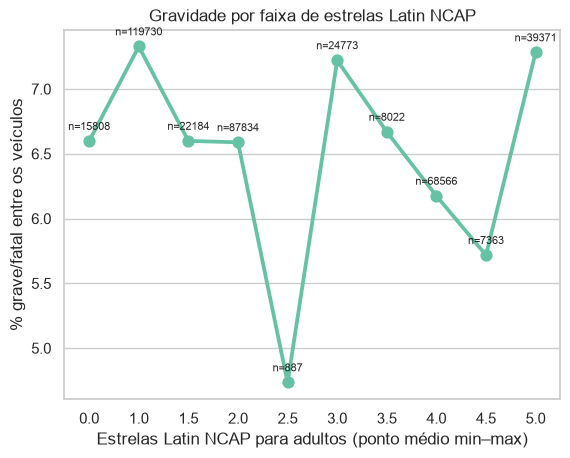

In [25]:
ax = sns.pointplot(
    data=gradiente_estrelas.reset_index(),
    x="latin_ncap_estrelas_adulto_media", y="taxa",
)
for x, (_, linha) in enumerate(gradiente_estrelas.iterrows()):
    ax.annotate(f"n={int(linha['n'])}", (x, linha["taxa"]), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)

ax.set(
    xlabel="Estrelas Latin NCAP para adultos (ponto médio min–max)",
    ylabel="% grave/fatal entre os veículos",
    title="Gravidade por faixa de estrelas Latin NCAP",
)

**Leitura do gráfico:** cada ponto é uma faixa de estrelas (incrementos de 0,5, porque é a média de
dois valores inteiros); o `n=` acima de cada ponto mostra quantos veículos sustentam aquele ponto;
faixas com `n` baixo pedem leitura mais cautelosa. Não há expectativa de queda contínua entre as
faixas: o objetivo é descrever a forma da relação, não confirmar uma tendência.

**Interpretação:** A proporção de gravidade grave/fatal varia numa faixa relativamente estreita
(entre 4,7% e 7,3%) ao longo dos níveis de estrelas Latin NCAP, sem um gradiente descendente claro
conforme a avaliação de segurança aumenta. O ponto de menor proporção (2,5 estrelas) tem amostra
pequena (n=887) frente às demais faixas e deve ser lido com cautela. Notavelmente, a faixa de maior
avaliação (5,0 estrelas, n=39.371) apresenta proporção próxima à da faixa de menor avaliação (1,0
estrela, n=119.730), o que não sustenta, neste recorte, uma relação simples entre mais estrelas e
menor gravidade. A comparação é exploratória: preço, idade do veículo, ano, protocolo de teste e
contexto do sinistro não estão controlados aqui e podem estar relacionados tanto às estrelas quanto
à gravidade.

##### Decis de preço FIPE

Usamos `decil_preco_fipe` (já calculado na base `veiculos` a partir do preço mediano da FIPE) para
comparar a gravidade entre faixas de valor de mercado do veículo. Por ser baseado em decis, cada
faixa tem, em teoria, o mesmo número de veículos, exceto quando há muitos valores empatados, que
podem reduzir o número efetivo de grupos distintos.

In [21]:
gradiente_preco = taxa_por_categoria(
    veiculos, "decil_preco_fipe",
    coluna_alvo="grave_fatal_veiculo", minimo=N_MINIMO,
).sort_index()

gradiente_preco

,n,positivos,taxa
decil_preco_fipe,,,
1.0,39639,2612,6.589470
2.0,39672,2892,7.289776
3.0,43043,2814,6.537648
4.0,35711,2620,7.336675
5.0,39327,2566,6.524779
6.0,39934,2690,6.736115
7.0,38618,2467,6.388213
8.0,39835,2750,6.903477
9.0,39080,2641,6.757932


[Text(0.5, 0, 'Decil de preço FIPE (1 = mais barato, 10 = mais caro)'),
 Text(0, 0.5, '% grave/fatal entre os veículos'),
 Text(0.5, 1.0, 'Gravidade por decil de preço FIPE')]

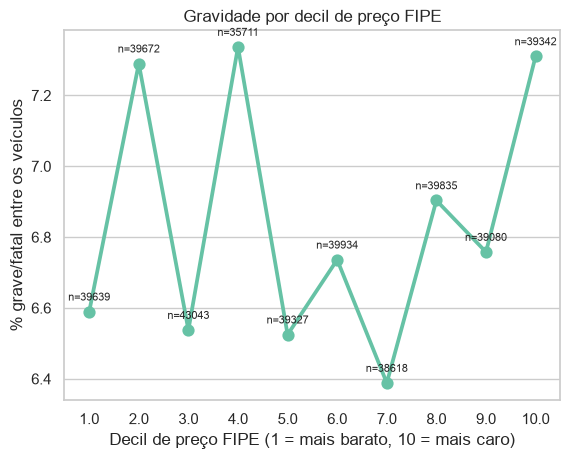

In [26]:
ax = sns.pointplot(
    data=gradiente_preco.reset_index(),
    x="decil_preco_fipe", y="taxa",
)
for x, (_, linha) in enumerate(gradiente_preco.iterrows()):
    ax.annotate(f"n={int(linha['n'])}", (x, linha["taxa"]), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)

ax.set(
    xlabel="Decil de preço FIPE (1 = mais barato, 10 = mais caro)",
    ylabel="% grave/fatal entre os veículos",
    title="Gravidade por decil de preço FIPE",
)

**Interpretação:** A proporção de gravidade grave/fatal também varia numa faixa estreita entre os
decis de preço FIPE (6,39% a 7,34%), sem tendência clara de queda conforme o valor do veículo
aumenta. O decil 4 tem a maior proporção (7,34%, n=35.711) e o decil 7 a menor (6,39%, n=38.618),
mas os valores intermediários oscilam sem um padrão monotônico visível. Os n ficaram equilibrados
entre os dez grupos (entre 35 e 43 mil veículos cada), então a oscilação não parece efeito de
amostra pequena em nenhum decil específico. Assim como no gradiente de estrelas, o resultado não
sustenta, neste recorte, uma associação simples entre valor de mercado e menor gravidade. A
comparação segue exploratória: características do veículo, do trajeto e do sinistro não estão
controladas nesta etapa.

### Pergunta 6 - Essa associação se sustenta em uma regressão linear com controles observáveis?

(preencher)

**Interpretação:** *(preencher)*

### Pergunta 7 - Onde os casos graves/fatais se concentram geograficamente?

(preencher)

**Interpretação:** *(preencher)*

### Pergunta 8 - Como essa relação varia entre tipos de sinistro, e quão sensível é ao critério de pareamento com o Latin NCAP?

(preencher)

**Interpretação:** *(preencher)*